In [ ]:
from tqdm.notebook import tqdm
import gzip
from netCDF4 import Dataset as DatasetNetCDF4
import numpy as np
import shutil
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.linalg import vector_norm
import torch.optim as optim
from PIL import Image
import torchvision
from torchvision import transforms
from torchvision.transforms.functional import crop
import shutil
from pickle import load
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import mean_squared_error as mse

### CMEMS Data Preprocessing

With a small script, we tested the mask od each patch to see if it contains the ground (False value for a pixel)

(1, 1, 481, 781)


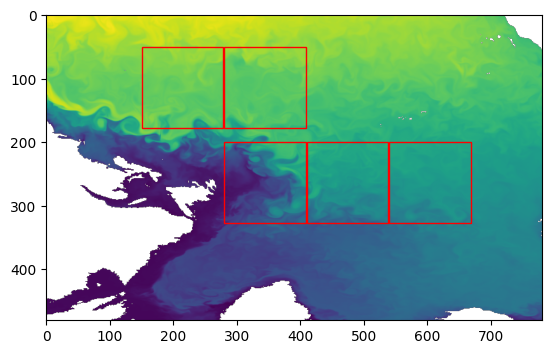

In [6]:
filename = "../DATA/CMENS_DATA/CMEMS_DATA/NATL_AN_2007-02-09.nc.gz"

gz = gzip.open(filename)

ds = DatasetNetCDF4('dummy', mode='r', memory=gz.read())
T = ds['thetao'][:]
print(T.shape)
T = T[0,0]

fig, ax = plt.subplots()

ax.imshow(T)

rect1 = patches.Rectangle((150, 50), 128, 128, linewidth=1, edgecolor='r', facecolor='none')
rect2 = patches.Rectangle((280, 50), 128, 128, linewidth=1, edgecolor='r', facecolor='none')
rect3 = patches.Rectangle((280, 200), 128, 128, linewidth=1, edgecolor='r', facecolor='none')
rect4 = patches.Rectangle((410, 200), 128, 128, linewidth=1, edgecolor='r', facecolor='none')
rect5 = patches.Rectangle((540, 200), 128, 128, linewidth=1, edgecolor='r', facecolor='none')


ax.add_patch(rect1)
ax.add_patch(rect2)
ax.add_patch(rect3)
ax.add_patch(rect4)
ax.add_patch(rect5)

plt.show()


In [14]:
root = "../DATA/CMENS_DATA/CMEMS_DATA/"

#filename = "DATA/CMENS_DATA/CMEMS_DATA/NATL_AN_2007-02-09.nc.gz"

if not os.path.exists("../DATA/CMENS_DATA_PATCHES_V2/CROP_0"):
    os.makedirs("../DATA/CMENS_DATA_PATCHES_V2/CROP_0")

if not os.path.exists("../DATA/CMENS_DATA_PATCHES_V2/CROP_1"):
    os.makedirs("../DATA/CMENS_DATA_PATCHES_V2/CROP_1")

if not os.path.exists("../DATA/CMENS_DATA_PATCHES_V2/CROP_2"):
    os.makedirs("../DATA/CMENS_DATA_PATCHES_V2/CROP_2")

if not os.path.exists("../DATA/CMENS_DATA_PATCHES_V2/CROP_3"):
    os.makedirs("../DATA/CMENS_DATA_PATCHES_V2/CROP_3")

if not os.path.exists("../DATA/CMENS_DATA_PATCHES_V2/CROP_4"):
    os.makedirs("../DATA/CMENS_DATA_PATCHES_V2/CROP_4")

for root, _, filenames in os.walk(root):
    for filename in filenames:
        with gzip.open(root + filename) as gz:
            ds = DatasetNetCDF4('dummy', mode='r', memory=gz.read())
            temperature = ds['thetao'][:] # extract only the temperature map
            temperature = torch.tensor(temperature)

            frame_name = filename.replace(".nc.gz", "")

            torch.save(crop(temperature, 50, 150, 128, 128), "../DATA/CMENS_DATA_PATCHES_V2/CROP_0/" + frame_name + ".pt")
            torch.save(crop(temperature, 50, 280, 128, 128), "../DATA/CMENS_DATA_PATCHES_V2/CROP_1/" + frame_name + ".pt")
            torch.save(crop(temperature, 200, 280, 128, 128), "../DATA/CMENS_DATA_PATCHES_V2/CROP_2/" + frame_name + ".pt")
            torch.save(crop(temperature, 200, 410, 128, 128), "../DATA/CMENS_DATA_PATCHES_V2/CROP_3/" + frame_name + ".pt")
            torch.save(crop(temperature, 200, 540, 128, 128), "../DATA/CMENS_DATA_PATCHES_V2/CROP_4/" + frame_name + ".pt")
            

#### Split into Train, test and validation sets and save on disk

In [2]:
root_tensors = "../DATA/CMENS_DATA_PATCHES_V2/"
if not os.path.exists(root_tensors + "TRAIN/CROP_0/"):
    os.makedirs(root_tensors + "TRAIN/CROP_0/")

if not os.path.exists(root_tensors + "TRAIN/CROP_1/"):
    os.makedirs(root_tensors + "TRAIN/CROP_1/")

if not os.path.exists(root_tensors + "TRAIN/CROP_2/"):
    os.makedirs(root_tensors + "TRAIN/CROP_2/")

if not os.path.exists(root_tensors + "TRAIN/CROP_3/"):
    os.makedirs(root_tensors + "TRAIN/CROP_3/")

if not os.path.exists(root_tensors + "TRAIN/CROP_4/"):
    os.makedirs(root_tensors + "TRAIN/CROP_4/")


if not os.path.exists(root_tensors + "TEST/CROP_0/"):
    os.makedirs(root_tensors + "TEST/CROP_0/")

if not os.path.exists(root_tensors + "TEST/CROP_1/"):
    os.makedirs(root_tensors + "TEST/CROP_1/")

if not os.path.exists(root_tensors + "TEST/CROP_2/"):
    os.makedirs(root_tensors + "TEST/CROP_2/")

if not os.path.exists(root_tensors + "TEST/CROP_3/"):
    os.makedirs(root_tensors + "TEST/CROP_3/")

if not os.path.exists(root_tensors + "TEST/CROP_4/"):
    os.makedirs(root_tensors + "TEST/CROP_4/")
    

if not os.path.exists(root_tensors + "VAL/CROP_0/"):
    os.makedirs(root_tensors + "VAL/CROP_0/")

if not os.path.exists(root_tensors + "VAL/CROP_1/"):
    os.makedirs(root_tensors + "VAL/CROP_1/")

if not os.path.exists(root_tensors + "VAL/CROP_2/"):
    os.makedirs(root_tensors + "VAL/CROP_2/")

if not os.path.exists(root_tensors + "VAL/CROP_3/"):
    os.makedirs(root_tensors + "VAL/CROP_3/")

if not os.path.exists(root_tensors + "VAL/CROP_4/"):
    os.makedirs(root_tensors + "VAL/CROP_4/")

In [3]:
files = os.listdir(root_tensors + "CROP_0/")

number_crop = 5

d = {"TEST": 180, "VAL": 180, "TRAIN": len(files)-360}

for name, size in d.items():
    for crop in range(number_crop):
        i = 0
        for root, _, filenames in os.walk(root_tensors + "CROP_" + str(crop) + "/"):
            while i < size:
                filename = filenames[i]
                source = root + filename
                destination = root_tensors + name + "/CROP_" + str(crop) + "/" + filename
                shutil.move(source, destination)
                i += 1

print("Data preparation complete.")

FileNotFoundError: [WinError 3] The system cannot find the path specified: '../DATA/CMENS_DATA_PATCHES_V2/CROP_0/'

## Datasets and Dataloaders

In [2]:
class DatasetNCFiles(Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.frames = []
        self.transform = transform

        # Check if root directory exists
        if not os.path.exists(self.root):
            raise ValueError(f"Root directory {self.root} does not exist.")

        # Load datasets paths
        self.crop_dirs = os.listdir(self.root)

        for crop_dir in self.crop_dirs:
            full_dir_path = os.path.join(self.root, crop_dir)

            if not os.path.isdir(full_dir_path):
                continue

            crops = os.listdir(full_dir_path)
            crops.sort()
            s = len(crops)
            valid_count = s - s % 7
            crops = crops[:valid_count]
            crops = [os.path.join(crop_dir, crop) for crop in crops]
            self.frames.extend(crops)

    def __len__(self):
        return len(self.frames) // 7

    def __getitem__(self, idx):
        # compute start index
        start_idx = idx * 7

        if start_idx + 6 >= len(self.frames):
            raise IndexError("Index out of range")
        
        # At least 7 frames left in the dataset
        T = self.frames[start_idx:start_idx+7]

        I0 = torch.load(os.path.join(self.root, T[0]), map_location='cpu')
        I1 = torch.load(os.path.join(self.root, T[3]), map_location='cpu')
        I2 = torch.load(os.path.join(self.root, T[6]), map_location='cpu')

        if self.transform:
            I0 = self.transform(I0) if self.transform else I0
            I1 = self.transform(I1) if self.transform else I1
            I2 = self.transform(I2) if self.transform else I2

        return I0, I1, I2

In [3]:
class TestDatasetNCFiles(Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.frames = []
        self.transform = transform

        # Check if root directory exists
        if not os.path.exists(self.root):
            raise ValueError(f"Root directory {self.root} does not exist.")

        # Load datasets paths
        self.crop_dirs = os.listdir(self.root)

        for crop_dir in self.crop_dirs:
            full_dir_path = os.path.join(self.root, crop_dir)

            if not os.path.isdir(full_dir_path):
                continue

            crops = os.listdir(full_dir_path)
            crops.sort()
            s = len(crops)
            valid_count = s - s % 4
            crops = crops[:valid_count]
            crops = [os.path.join(crop_dir, crop) for crop in crops]
            self.frames.extend(crops)

    # Concatenate the n first images in one tensor on dimension 0 which is time dimension
    def get_n_frames_in_one_tensor(self, n):
        tensor = None
        for i, frame_name in enumerate(self.frames):
            if i < n:
                if tensor == None:
                    tensor = torch.load(os.path.join(self.root, frame_name), map_location='cpu')
                else:
                    frame = torch.load(os.path.join(self.root, frame_name), map_location='cpu')
                    tensor = torch.cat((tensor, frame), 0)

        tensor = self.transform(tensor) if self.transform else tensor
        return tensor
    
    # Concatenate all images in one tensor on dimension 0 which is time dimension
    def get_all_frames_in_one_tensor(self):
        tensor = None
        for frame_name in self.frames:
            if tensor == None:
                tensor = torch.load(os.path.join(self.root, frame_name), map_location='cpu')
            else:
                frame = torch.load(os.path.join(self.root, frame_name), map_location='cpu')
                tensor = torch.cat((tensor, frame), 0)

        tensor = self.transform(tensor) if self.transform else tensor
        return tensor

    def __len__(self):
        return len(self.frames) // 4

    def __getitem__(self, idx):
        # compute start index
        start_idx = idx * 4

        if start_idx + 3 >= len(self.frames):
            raise IndexError("Index out of range")
        
        # At least 4 frames left in the dataset
        T = self.frames[start_idx:start_idx+4]

        I0 = torch.load(os.path.join(self.root, T[0]), map_location='cpu')
        I1 = torch.load(os.path.join(self.root, T[1]), map_location='cpu')
        I2 = torch.load(os.path.join(self.root, T[2]), map_location='cpu')
        I3 = torch.load(os.path.join(self.root, T[3]), map_location='cpu')

        if self.transform:
            I0 = self.transform(I0) if self.transform else I0
            I1 = self.transform(I1) if self.transform else I1
            I2 = self.transform(I2) if self.transform else I2
            I3 = self.transform(I3) if self.transform else I3

        return I0, I1, I2, I3

In [4]:
DATA_MIN = 10.0
DATA_MAX = 30.0

transform = transforms.Compose([
    transforms.Lambda(lambda x: x.float()),
    transforms.Lambda(lambda x: (x - DATA_MIN) / (DATA_MAX - DATA_MIN)),
    transforms.Lambda(lambda x: x.reshape(1, 128, 128)),
    
    ])

## Neural Network U-Net

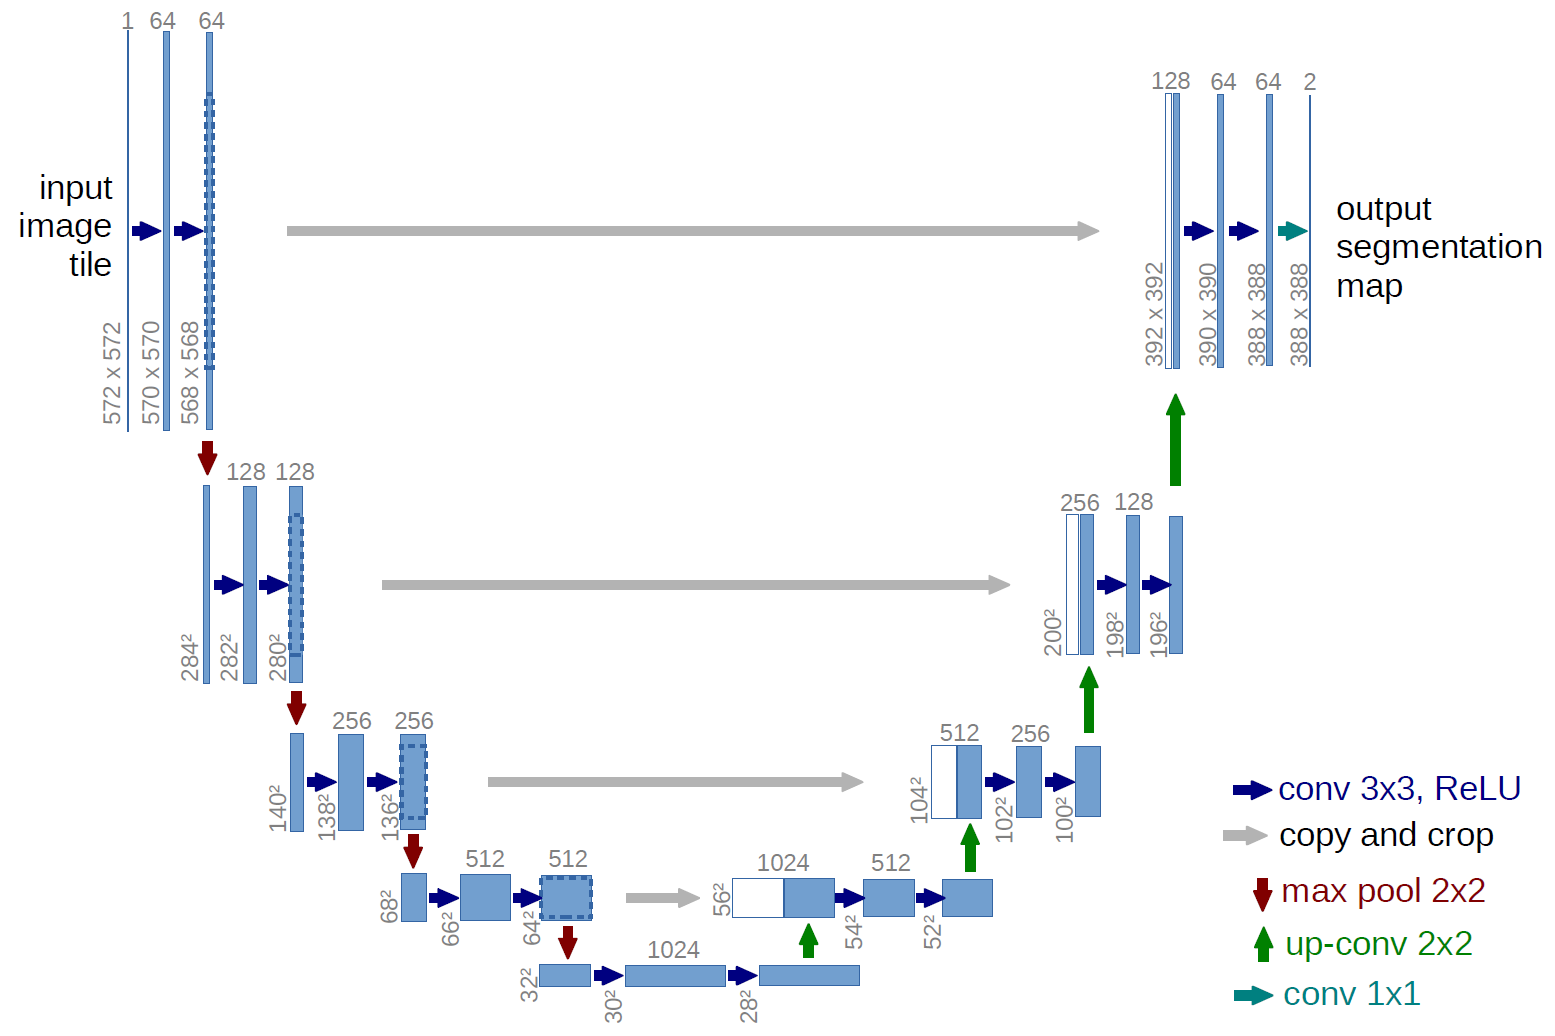

In [7]:
from IPython.display import Image as I
I(filename="external model/Baseline model/u-net-architecture.png") 

In [5]:
# Coder les bases lines
# Int lin et bicubique
# TV1_pock ou tv_l1 (flow optic) dans opencv ou skimage optical_flow_tv_l1
# 

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=(3,3), padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=(3,3), padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.double_conv(x)

In [6]:
class Up(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(Up, self).__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=1, stride=1)
        self.double_conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x = self.up(x1)
        x = torch.cat([x, x2], dim=1)
        return self.double_conv(x)

In [7]:
class UNet(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(UNet, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels

        # Encoder Layers
        self.enc = DoubleConv(self.in_channels, 64)
        self.pool = nn.MaxPool2d(2)
        self.down1 = DoubleConv(64, 128)
        self.down2 = DoubleConv(128, 256)
        self.down3 = DoubleConv(256, 512)
        self.down4 = DoubleConv(512, 1024)

        # Decoder Layers
        self.dec1 = Up(1024, 512)
        self.dec2 = Up(512, 256)
        self.dec3 = Up(256, 128)
        self.dec4 = Up(128, 64)
        self.outc = nn.Conv2d(64, self.out_channels, kernel_size=1)

    def forward(self, x):

        # Encoder
        x1 = self.enc(x)
        x2 = self.down1(self.pool(x1))
        x3 = self.down2(self.pool(x2))
        x4 = self.down3(self.pool(x3))
        x5 = self.down4(self.pool(x4))

        # Decoder
        out = self.dec1(x5)
        out = self.dec2(out)
        out = self.dec3(out)
        out = self.dec4(out)

        return self.outc(out)

In [8]:
class SEBlock(nn.Module):
    def __init__(self, in_channels, r=16):
        super(SEBlock, self).__init__()
        self.squeeze = nn.AdaptiveAvgPool2d(1)
        self.excitation = nn.Sequential(
            nn.Linear(in_channels, in_channels // r, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(in_channels // r, in_channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        bs, c, _, _ = x.size()
        y = self.squeeze(x).view(bs, c)
        y = self.excitation(y).view(bs, c, 1, 1)
        return x * y.expand_as(x)

In [9]:
class UNetSE(nn.Module):
    def __init__(self, channels):
        super(UNetSE, self).__init__()
        self.channels = channels

        # Encoder Layers
        self.enc = DoubleConv(self.channels, 64)
        self.down_se_enc = SEBlock(64)
        self.down1 = DoubleConv(64, 128)
        self.down_se1 = SEBlock(128)
        self.down2 = DoubleConv(128, 256)
        self.down_se2 = SEBlock(256)
        self.down3 = DoubleConv(256, 512)
        self.down_se3 = SEBlock(512)
        self.down4 = DoubleConv(512, 1024)
        self.down_se4 = SEBlock(1024)


        # Decoder Layers
        self.dec1 = Up(1024, 512)
        self.up_se1 = SEBlock(512)
        self.dec2 = Up(512, 256)
        self.up_se2 = SEBlock(256)
        self.dec3 = Up(256, 128)
        self.up_se3 = SEBlock(128)
        self.dec4 = Up(128, 64)
        self.up_se4 = SEBlock(64)
        self.outc = nn.Conv2d(64, self.channels, kernel_size=1)

    def forward(self, I0, I1):
        # I0: batch, channel, width, height
        x = torch.cat([I0, I1], dim=1) # We concatenate along channel dimension
        # Encoder
        x1 = self.down_se_enc(self.enc(x))
        x2 = self.down_se1(self.down1(x1))
        x3 = self.down_se2(self.down2(x2))
        x4 = self.down_se3(self.down3(x3))
        x5 = self.down_se4(self.down4(x4))

        # Decoder
        out = self.up_se1(self.dec1(x5, x4))
        out = self.up_se2(self.dec2(out, x3))
        out = self.up_se3(self.dec3(out, x2))
        out = self.up_se4(self.dec4(out, x1))
        out = self.outc(out)

        return torch.chunk(out, chunks=2, dim=1)

## Tranning

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [11]:
dataset = DatasetNCFiles(root="../DATA/CMENS_DATA_PATCHES_V2/TRAIN/", transform=transform)
val_dataset = DatasetNCFiles(root="../DATA/CMENS_DATA_PATCHES_V2/VAL/", transform=transform)
print("Dataset length:", len(dataset))
print("Validation Dataset length:", len(val_dataset))

loader = DataLoader(dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

Dataset length: 2410
Validation Dataset length: 125


In [15]:
enc = DoubleConv(2, 64).to(device)
down_se_enc = SEBlock(64).to(device)
down1 = DoubleConv(64, 128).to(device)
down_se1 = SEBlock(128).to(device)
down2 = DoubleConv(128, 256).to(device)
down_se2 = SEBlock(256).to(device)
down3 = DoubleConv(256, 512).to(device)
down_se3 = SEBlock(512).to(device)
down4 = DoubleConv(512, 1024).to(device)
down_se4 = SEBlock(1024).to(device)

dec1 = Up(1024, 512).to(device)
up_se1 = SEBlock(512).to(device)
dec2 = Up(512, 256).to(device)
up_se2 = SEBlock(256).to(device)
dec3 = Up(256, 128).to(device)
up_se3 = SEBlock(128).to(device)
dec4 = Up(128, 64).to(device)
up_se4 = SEBlock(64).to(device)
outc = nn.Conv2d(64, 2, kernel_size=1).to(device)

for i0, i1, i2 in loader:
    print(i0.shape)
    i = torch.cat([i0, i1], dim=1)
    print("Input shape:", i.shape)
    i = i.to(device).float()
    x1 = enc(i)
    print("After enc shape:", x1.shape)
    x1 = down_se_enc(x1)
    print("After SE enc shape:", x1.shape)
    x2 = down1(x1)
    print("After down1 shape:", x2.shape)
    x2 = down_se1(x2)
    print("After SE1 shape:", x2.shape)
    x3 = down2(x2)
    print("After down2 shape:", x3.shape)
    x3 = down_se2(x3)
    print("After SE2 shape:", x3.shape)
    x4 = down3(x3)
    print("After down3 shape:", x4.shape)
    x4 = down_se3(x4)
    print("After SE3 shape:", x4.shape)
    x5 = down4(x4)
    print("After down4 shape:", x5.shape)
    x5 = down_se4(x5)
    print("After SE4 shape:", x5.shape)

    i = dec1(x5, x4)
    print("After dec1 shape:", i.shape)
    i = up_se1(i)
    print("After up SE1 shape:", i.shape)
    i = dec2(i, x3)
    print("After dec2 shape:", i.shape)
    i = up_se2(i)
    print("After up SE2 shape:", i.shape)
    i = dec3(i, x2)
    print("After dec3 shape:", i.shape)
    i = up_se3(i)
    print("After up SE3 shape:", i.shape)
    i = dec4(i, x1)
    print("After dec4 shape:", i.shape)
    i = up_se4(i)
    print("After up SE4 shape:", i.shape)
    a = outc(i)
    print("Output shape:", a.shape)
    break


torch.Size([4, 1, 128, 128])
Input shape: torch.Size([4, 2, 128, 128])
After enc shape: torch.Size([4, 64, 128, 128])
After SE enc shape: torch.Size([4, 64, 128, 128])
After down1 shape: torch.Size([4, 128, 128, 128])
After SE1 shape: torch.Size([4, 128, 128, 128])
After down2 shape: torch.Size([4, 256, 128, 128])
After SE2 shape: torch.Size([4, 256, 128, 128])
After down3 shape: torch.Size([4, 512, 128, 128])
After SE3 shape: torch.Size([4, 512, 128, 128])
After down4 shape: torch.Size([4, 1024, 128, 128])
After SE4 shape: torch.Size([4, 1024, 128, 128])
After dec1 shape: torch.Size([4, 512, 128, 128])
After up SE1 shape: torch.Size([4, 512, 128, 128])
After dec2 shape: torch.Size([4, 256, 128, 128])
After up SE2 shape: torch.Size([4, 256, 128, 128])
After dec3 shape: torch.Size([4, 128, 128, 128])
After up SE3 shape: torch.Size([4, 128, 128, 128])
After dec4 shape: torch.Size([4, 64, 128, 128])
After up SE4 shape: torch.Size([4, 64, 128, 128])
Output shape: torch.Size([4, 2, 128, 128

In [12]:
model = UNetSE(2)
model.to(device)

UNetSE(
  (enc): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(2, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down_se_enc): SEBlock(
    (squeeze): AdaptiveAvgPool2d(output_size=1)
    (excitation): Sequential(
      (0): Linear(in_features=64, out_features=4, bias=False)
      (1): ReLU(inplace=True)
      (2): Linear(in_features=4, out_features=64, bias=False)
      (3): Sigmoid()
    )
  )
  (down1): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplac

#### Loss

In [13]:
class LCC(nn.Module):
    def __init__(self):
        super(LCC, self).__init__()
        self.criterion = nn.L1Loss()

    def forward(self, I1, s1_pred2, s1_pred3, s2_pred1, s2_pred2, s2_pred3, s2_pred4, alpha):
        LCC1 = self.criterion(s2_pred2, I1) + self.criterion(s2_pred3, I1)
        LCC2 = 0.5 * (self.criterion(s2_pred1, s1_pred2) + self.criterion(s2_pred4, s1_pred3))

        return alpha * LCC1 + (1-alpha) * LCC2

# After training the model

### Test on temperature dataset

In [15]:
train_losses = load(open("../OUTPUTS/30_epochs/train losses", "rb"))
val_losses = load(open("../OUTPUTS/30_epochs/validation losses", "rb"))

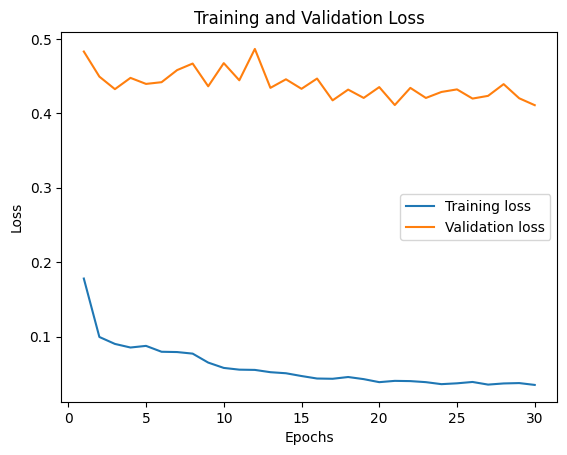

In [16]:
epochs = range(1, len(train_losses) + 1)

plt.plot(epochs, train_losses, label='Training loss')
plt.plot(epochs, val_losses, label='Validation loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
  
plt.legend(loc='best')
plt.show()

In [17]:
model =UNetSE(2)
model.load_state_dict(torch.load('../OUTPUTS/30_epochs/model_30_epochs.pth'))
model.to(device)
model.eval()

UNetSE(
  (enc): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(2, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down_se_enc): SEBlock(
    (squeeze): AdaptiveAvgPool2d(output_size=1)
    (excitation): Sequential(
      (0): Linear(in_features=64, out_features=4, bias=False)
      (1): ReLU(inplace=True)
      (2): Linear(in_features=4, out_features=64, bias=False)
      (3): Sigmoid()
    )
  )
  (down1): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplac

In [18]:
root="../DATA/CMENS_DATA_PATCHES_V2/TEST/"

test_dataset = DatasetNCFiles(root, transform=transform)
print("Test Dataset length:", len(test_dataset))

loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

Test Dataset length: 125


torch.float32
tensor(0.2223, device='cuda:0')
tensor(0.6881, device='cuda:0')
0.2101234
0.67114353
0.15344551
0.669381
tensor(0.1347, device='cuda:0')
tensor(0.6766, device='cuda:0')


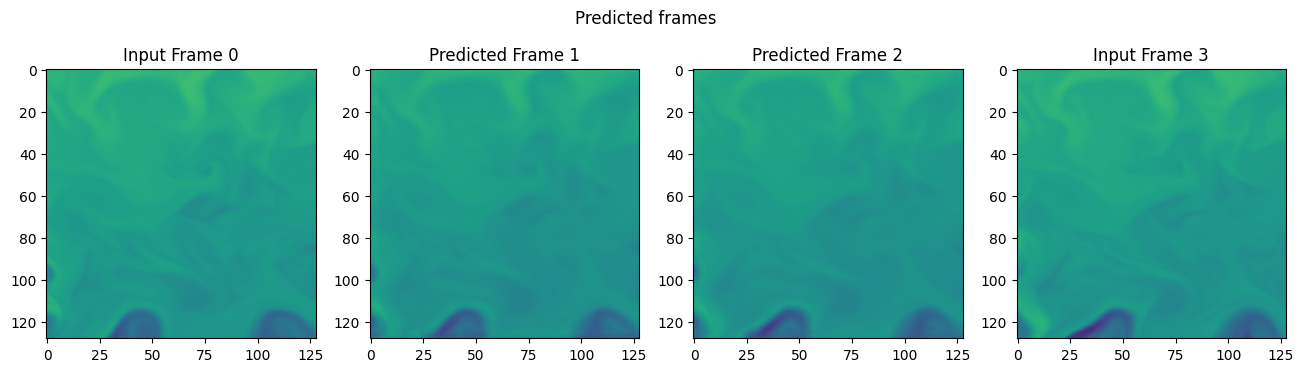

In [55]:
frame0 = torch.load(os.path.join(root, "CROP_0/NATL_AN_2006-12-27.pt"), map_location='cpu')
frame3 = torch.load(os.path.join(root, "CROP_0/NATL_AN_2006-12-30.pt"), map_location='cpu')

frame0 = transform(frame0).to(device).unsqueeze(0)
frame3 = transform(frame3).to(device).unsqueeze(0)
print(frame0.dtype)

frame0 = frame0.to(device)
frame3 = frame3.to(device)

frame1, frame2 = model(frame0, frame3)

frame1 = frame1.detach().cpu().numpy().squeeze()
frame2 = frame2.detach().cpu().numpy().squeeze()

print(torch.min(frame0))
print(torch.max(frame0))

print(np.min(frame1))
print(np.max(frame1))

print(np.min(frame2))
print(np.max(frame2))

print(torch.min(frame3))
print(torch.max(frame3))

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Predicted frames")

ax1.imshow(frame0.detach().cpu().numpy().squeeze(), cmap='viridis', vmin=0, vmax=1)
ax1.set_title("Input Frame 0")

ax2.imshow(frame1, cmap='viridis', vmin=0, vmax=1)
ax2.set_title("Predicted Frame 1")
ax3.imshow(frame2, cmap='viridis', vmin=0, vmax=1)
ax3.set_title("Predicted Frame 2")

ax4.imshow(frame3.detach().cpu().numpy().squeeze(), cmap='viridis', vmin=0, vmax=1)
ax4.set_title("Input Frame 3")
plt.show()


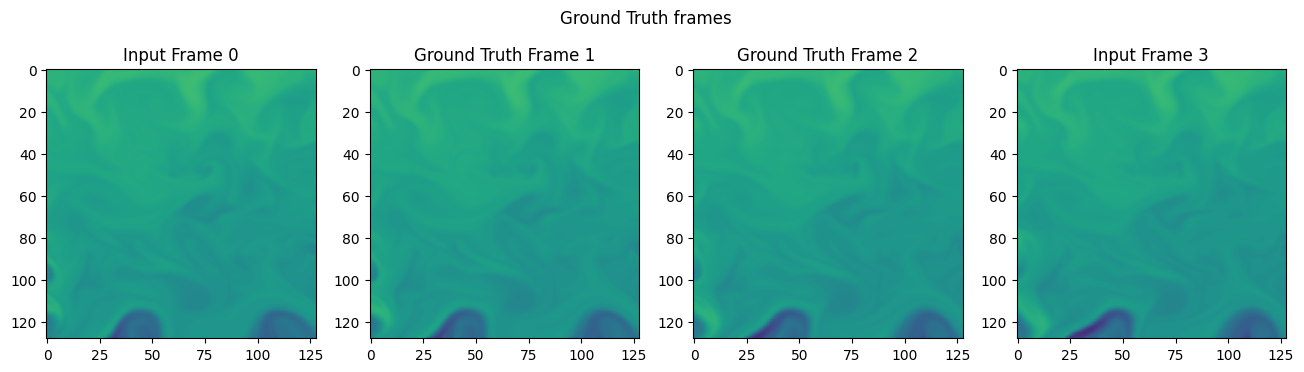

In [20]:
frame1_gt = torch.load(os.path.join(root, "CROP_0/NATL_AN_2006-12-28.pt"), map_location='cpu')
frame2_gt = torch.load(os.path.join(root, "CROP_0/NATL_AN_2006-12-29.pt"), map_location='cpu')

frame1_gt = transform(frame1_gt).squeeze()
frame2_gt = transform(frame2_gt).squeeze()

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Ground Truth frames")

ax1.imshow(frame0.detach().cpu().numpy().squeeze(), cmap='viridis', vmin=0, vmax=1)
ax1.set_title("Input Frame 0")

ax2.imshow(frame1_gt, cmap='viridis', vmin=0, vmax=1)
ax2.set_title("Ground Truth Frame 1")
ax3.imshow(frame2_gt, cmap='viridis', vmin=0, vmax=1)
ax3.set_title("Ground Truth Frame 2")

ax4.imshow(frame3.detach().cpu().numpy().squeeze(), cmap='viridis', vmin=0, vmax=1)
ax4.set_title("Input Frame 3")
plt.show()

In [21]:
testset = TestDatasetNCFiles(root="../DATA/CMENS_DATA_PATCHES_V2/TEST/", transform=transform)
print("Test set length:", len(testset))

testloader = DataLoader(testset, batch_size=1, shuffle=True)

Test set length: 225


In [33]:
ssim_metrics = 0
psnr_metrics = 0
mse_metrics = 0

with torch.no_grad():
    for I0, I1, I2, I3 in testloader:
        I0 = I0.to(device).float()
        I3 = I3.to(device).float()

        I1 = I1.numpy().squeeze()
        I2 = I2.numpy().squeeze()

        I1_hat, I2_hat = model(I0, I3)
        I1_hat = I1_hat.detach().cpu().numpy().squeeze()
        I2_hat = I2_hat.detach().cpu().numpy().squeeze()

        ssim_metrics += ssim(I1, I1_hat, data_range=1)
        ssim_metrics += ssim(I2, I2_hat, data_range=1)

        psnr_metrics += psnr(I1, I1_hat)
        psnr_metrics += psnr(I2, I2_hat)

        mse_metrics += mse(I1, I1_hat)
        mse_metrics += mse(I2, I2_hat)

    print(f"SSIM = {ssim_metrics / (len(testloader) * 2)}")
    print(f"PSNR = {psnr_metrics / (len(testloader) * 2)}")
    print(f"MSE = {mse_metrics / (len(testloader) * 2)}")

SSIM = 0.947988578735634
PSNR = 37.874421274094544
MSE = 0.0006232979220600912


### Test on UCF101

In [22]:
transform = transforms.Compose([
    transforms.Lambda(lambda x: x.permute((0, 3, 1, 2))),
    transforms.Grayscale(num_output_channels=1),
    transforms.Lambda(lambda x: x.permute((1, 0, 2, 3))),
    transforms.Lambda(lambda x: x.float() / 255.0),
    transforms.Resize((128, 128))
])


ucf101 = torchvision.datasets.UCF101(
    root='../DATA/UCF101/data/', annotation_path='../DATA/UCF101/UCF101TrainTestSplits-RecognitionTask/ucfTrainTestlist/',
    frames_per_clip=4, train=False, transform=transform)

100%|██████████| 833/833 [06:08<00:00,  2.26it/s]


UCF101 test dataset length: 685867
Batch shape: torch.Size([1, 1, 4, 128, 128]) torch.Size([1, 1, 0]) torch.Size([1])


Text(0.5, 1.0, 'First frame of first video in batch')

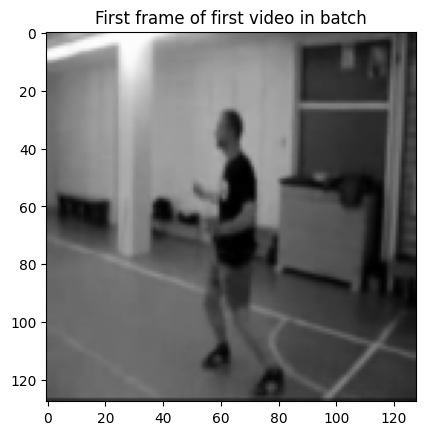

In [27]:
print("UCF101 test dataset length:", len(ucf101))
loader = DataLoader(ucf101, batch_size=1, shuffle=True)
vid, aud, label = next(iter(loader))
print("Batch shape:", vid.shape, aud.shape, label.shape)

plt.imshow(vid[0][0][0], cmap='gray', vmin=0, vmax=1)
plt.title("First frame of first video in batch")

In [28]:
#vid = vid.permute(0, 2, 1, 3, 4)
I0 = vid[:, :, 0, :, :].to(device)
I1 = vid[:, :, 1, :, :]
I2 = vid[:, :, 2, :, :]
I3 = vid[:, :, 3, :, :].to(device)
print(I0.shape)

I1_hat, I2_hat = model(I0, I3)

torch.Size([1, 1, 128, 128])


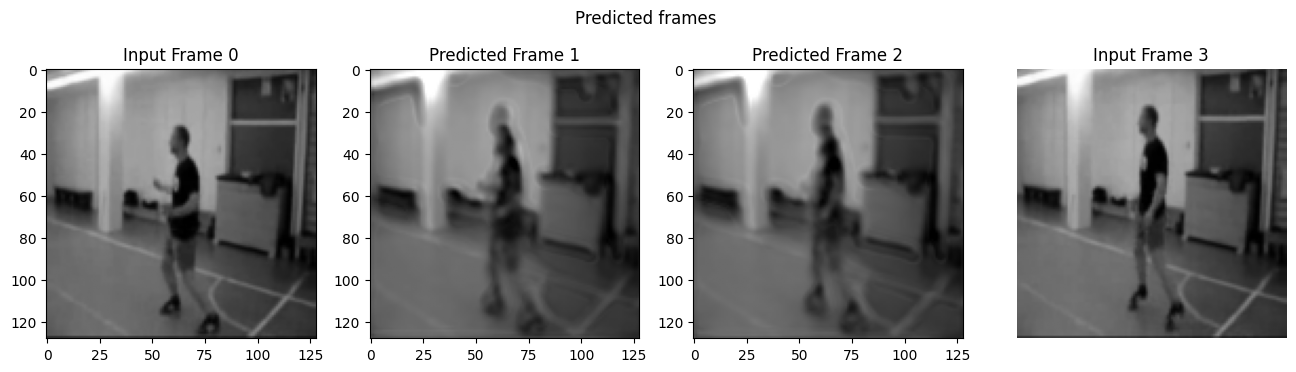

In [29]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Predicted frames")

ax1.imshow(I0.detach().cpu().numpy().squeeze(), cmap='gray', vmin=0, vmax=1)
ax1.set_title("Input Frame 0")

ax2.imshow(I1_hat.detach().cpu().numpy().squeeze(), cmap='gray', vmin=0, vmax=1)
ax2.set_title("Predicted Frame 1")
ax3.imshow(I2_hat.detach().cpu().numpy().squeeze(), cmap='gray', vmin=0, vmax=1)
ax3.set_title("Predicted Frame 2")

ax4.imshow(I3.detach().cpu().numpy().squeeze(), cmap='gray', vmin=0, vmax=1)
ax4.set_title("Input Frame 3")
plt.axis('off')
plt.show()

### Statistics

In [13]:
ssim_metrics = 0
psnr_metrics = 0
mse_metrics = 0

loader = DataLoader(ucf101, batch_size=1, shuffle=True)
with torch.no_grad():
    for vid, _, _ in loader:

        I0 = vid[:, :, 0, :, :].to(device)
        I1 = vid[:, :, 1, :, :]
        I2 = vid[:, :, 2, :, :]
        I3 = vid[:, :, 3, :, :].to(device)

        I1 = I1.numpy().squeeze()
        I2 = I2.numpy().squeeze()

        I1_hat, I2_hat = model(I0, I3)
        I1_hat = I1_hat.detach().cpu().numpy().squeeze()
        I2_hat = I2_hat.detach().cpu().numpy().squeeze()

        ssim_metrics += ssim(I1, I1_hat, data_range=1)
        ssim_metrics += ssim(I2, I2_hat, data_range=1)

        psnr_metrics += psnr(I1, I1_hat, data_range=1)
        psnr_metrics += psnr(I2, I2_hat, data_range=1)

        mse_metrics += mse(I1, I1_hat)
        mse_metrics += mse(I2, I2_hat)

    print(f"SSIM = {ssim_metrics / (len(loader) * 2)}")
    print(f"PSNR = {psnr_metrics / (len(loader) * 2)}")
    print(f"MSE = {mse_metrics / (len(loader) * 2)}")

f:\IMA\S3\PRAT\PRAT_venv\PRAT_venv\lib\site-packages\torchvision\io\_video_deprecation_warning.py:5: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(
f:\IMA\S3\PRAT\PRAT_venv\PRAT_venv\lib\site-packages\torchvision\io\video.py:199: UserWarning: The pts_unit 'pts' gives wrong results. Please use pts_unit 'sec'.
  warnings.warn("The pts_unit 'pts' gives wrong results. Please use pts_unit 'sec'.")


KeyboardInterrupt: 

# ----------------------------------------------------------

# Baselines

## Bicubic

### Loading data

In [6]:
DATA_MIN = 10.0
DATA_MAX = 30.0

transform = transforms.Compose([
    transforms.Lambda(lambda x: x.float()),
    transforms.Lambda(lambda x: (x - DATA_MIN) / (DATA_MAX - DATA_MIN)),
])

root = "../DATA/CMENS_DATA_PATCHES_V2/TEST/"
dataloader = TestDatasetNCFiles(root, transform=transform)

all_frames = dataloader.get_all_frames_in_one_tensor().numpy().astype(np.float32)
print(all_frames.shape)

ground_truths = [all_frames[0:180, :, :, :],
    all_frames[180:180*2, :, :, :],
    all_frames[180*2:180*3, :, :, :],
    all_frames[180*3:180*4, :, :, :],
    all_frames[180*4:180*5, :, :, :]
]

to_predict = []

for crop in ground_truths:
    to_predict.append(
        # Delete images to predict
        np.delete(crop, [i for i in range(crop.shape[0]) if i % 3 != 0], axis=0)
    )


(900, 1, 128, 128)


In [7]:
print(np.unique(ground_truths[0]))

[-0.22485276 -0.2228019  -0.22195959 ...  0.84495527  0.8452116
  0.84543145]


### Interpolation

In [8]:
from scipy.interpolate import interp1d

T = to_predict[0].shape[0]
original_time = np.arange(T)

new_time = np.linspace(0, T-1, num=int(T * 3))

f_crop = []

for crop_to_predict in to_predict:
    f_crop.append(
        interp1d(original_time, crop_to_predict, kind='cubic', axis=0)
    )

frames_interp = []
for crop in f_crop:
    frames_interp.append(
        crop(new_time)
    )

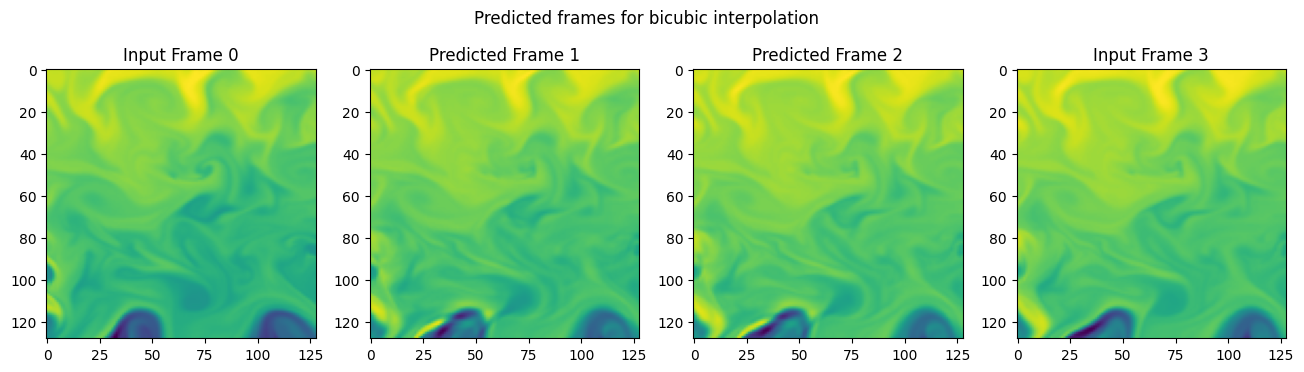

In [39]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Predicted frames for bicubic interpolation")

ax1.imshow(frames_interp[0][0].squeeze())
ax1.set_title("Input Frame 0")

ax2.imshow(frames_interp[0][1].squeeze())
ax2.set_title("Predicted Frame 1")
ax3.imshow(frames_interp[0][2].squeeze())
ax3.set_title("Predicted Frame 2")

ax4.imshow(frames_interp[0][3].squeeze())
ax4.set_title("Input Frame 3")
plt.show()


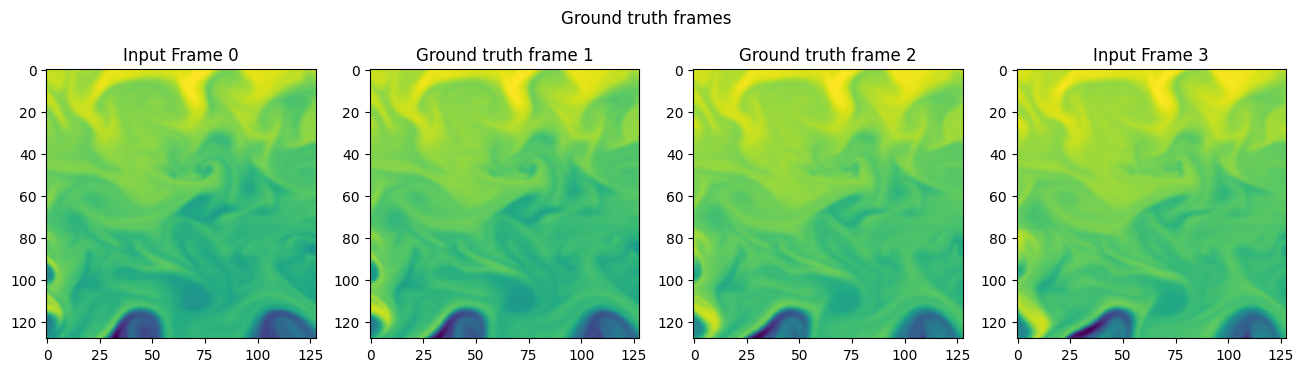

In [10]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Ground truth frames")

ax1.imshow(ground_truths[0][0].squeeze())
ax1.set_title("Input Frame 0")

ax2.imshow(ground_truths[0][1].squeeze())
ax2.set_title("Ground truth frame 1")
ax3.imshow(ground_truths[0][2].squeeze())
ax3.set_title("Ground truth frame 2")

ax4.imshow(ground_truths[0][3].squeeze())
ax4.set_title("Input Frame 3")
plt.show()


### Statistics

In [11]:
n_crops = 5

ssim_metrics = 0
psnr_metrics = 0
mse_metrics = 0

for i_crop in range(n_crops):
    i = 0
    while i < T:
        frame_interp_1 = frames_interp[i_crop][i+1, :, :, :].squeeze()
        frame_interp_2 = frames_interp[i_crop][i+2, :, :, :].squeeze()

        gt_frame_1 = ground_truths[i_crop][i+1, :, :, :].squeeze()
        gt_frame_2 = ground_truths[i_crop][i+2, :, :, :].squeeze()

        ssim_metrics += ssim(gt_frame_1, frame_interp_1, data_range=1)
        ssim_metrics += ssim(gt_frame_2, frame_interp_2, data_range=1)
        
        psnr_metrics += psnr(gt_frame_1, frame_interp_1, data_range=1)
        psnr_metrics += psnr(gt_frame_2, frame_interp_2, data_range=1)

        mse_metrics += mse(gt_frame_1, frame_interp_1)
        mse_metrics += mse(gt_frame_2, frame_interp_2)

        i += 4

print(f"SSIM = {ssim_metrics / (len(dataloader) * 2)}")
print(f"PSNR = {psnr_metrics / (len(dataloader) * 2)}")
print(f"MSE = {mse_metrics / (len(dataloader) * 2)}")

SSIM = 0.32600140044527953
PSNR = 15.176702127139643
MSE = 3.1513993674556884e-05


## Optical flow

In [29]:
import cv2

def compute_tvl1(frame0, frame2):
    frame0 = frame0.squeeze()
    frame2 = frame2.squeeze()

    tvl1 = tvl1 = cv2.optflow.DualTVL1OpticalFlow_create()
    flow = tvl1.calc(frame0, frame2, None)

    return flow

def get_intermediate_image(img0, flow, t=0.5):
    h, w = flow.shape[:2]
    
    grid_x, grid_y = np.meshgrid(np.arange(w), np.arange(h))
    
    map_x = (grid_x - (flow[..., 0] * t)).astype(np.float32)
    map_y = (grid_y - (flow[..., 1] * t)).astype(np.float32)

    warped_img = cv2.remap(img0, map_x, map_y, 
                           interpolation=cv2.INTER_CUBIC,
                           borderMode=cv2.BORDER_REFLECT)
    
    return warped_img

In [42]:
frame0 = ground_truths[1][0, :, :, :]
gt_frame1 = ground_truths[1][1, :, :, :]
gt_frame1 = ground_truths[1][2, :, :, :]
frame3 = ground_truths[1][3, :, :, :]
flow = compute_tvl1(frame0, frame3)

frame_interp_1 = get_intermediate_image(np.transpose(frame0, (1, 2, 0)), flow, t=1/3)
frame_interp_2 = get_intermediate_image(np.transpose(frame0, (1, 2, 0)), flow, t=2/3)

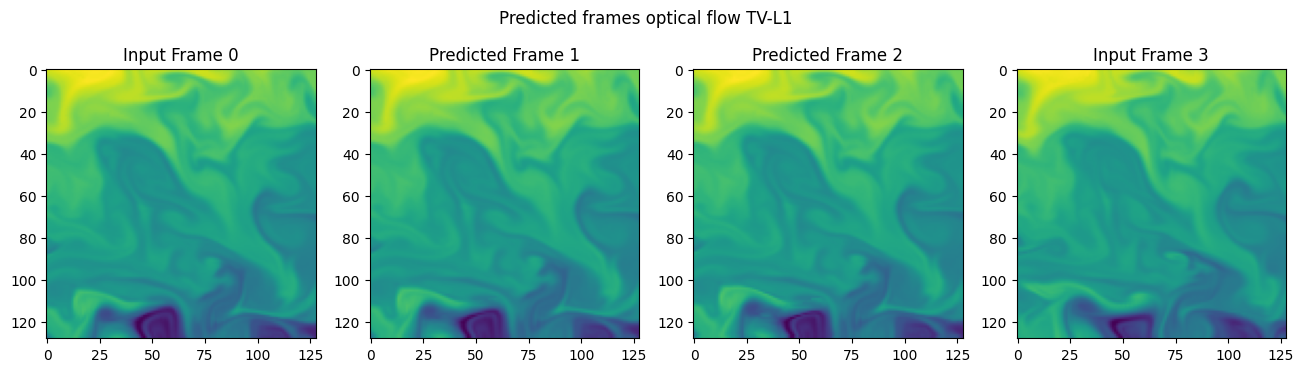

In [43]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Predicted frames optical flow TV-L1")

ax1.imshow(frame0.squeeze())
ax1.set_title("Input Frame 0")

ax2.imshow(frame_interp_1.squeeze())
ax2.set_title("Predicted Frame 1")
ax3.imshow(frame_interp_2.squeeze())
ax3.set_title("Predicted Frame 2")

ax4.imshow(frame3.squeeze())
ax4.set_title("Input Frame 3")
plt.show()

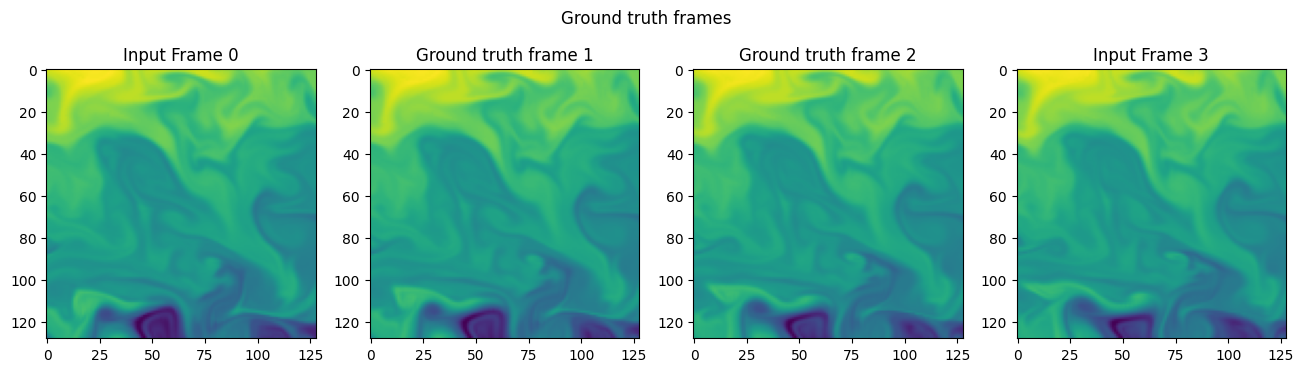

In [36]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Ground truth frames")

ax1.imshow(ground_truths[1][0].squeeze())
ax1.set_title("Input Frame 0")

ax2.imshow(ground_truths[1][1].squeeze())
ax2.set_title("Ground truth frame 1")
ax3.imshow(ground_truths[1][2].squeeze())
ax3.set_title("Ground truth frame 2")

ax4.imshow(ground_truths[1][3].squeeze())
ax4.set_title("Input Frame 3")
plt.show()


### Statistics

## Persistence

### Statistics

In [38]:
n_crops = 5

ssim_metrics = 0
psnr_metrics = 0
mse_metrics = 0

for i_crop in range(n_crops):
    i = 0
    while i < T:
        # Inputs
        frame0 = ground_truths[i_crop][i, :, :, :].squeeze()
        frame3 = ground_truths[i_crop][i+3, :, :, :].squeeze()

        # Interpolated frames
        frame_interp_1 = ground_truths[i_crop][i, :, :, :].squeeze()
        frame_interp_2 = ground_truths[i_crop][i+3, :, :, :].squeeze()

        # Ground truths
        gt_frame1 = ground_truths[i_crop][i+1, :, :, :].squeeze()
        gt_frame2 = ground_truths[i_crop][i+2, :, :, :].squeeze()

        ssim_metrics += ssim(gt_frame1, frame_interp_1, data_range=1)
        ssim_metrics += ssim(gt_frame2, frame_interp_2, data_range=1)
        
        psnr_metrics += psnr(gt_frame1, frame_interp_1, data_range=1)
        psnr_metrics += psnr(gt_frame2, frame_interp_2, data_range=1)

        mse_metrics += mse(gt_frame1, frame_interp_1)
        mse_metrics += mse(gt_frame2, frame_interp_2)

        i += 4

print(f"SSIM = {ssim_metrics / (len(dataloader) * 2)}")
print(f"PSNR = {psnr_metrics / (len(dataloader) * 2)}")
print(f"MSE = {mse_metrics / (len(dataloader) * 2)}")

SSIM = 0.3198394127473892
PSNR = 13.12755897615396
MSE = 6.64822646305592e-05


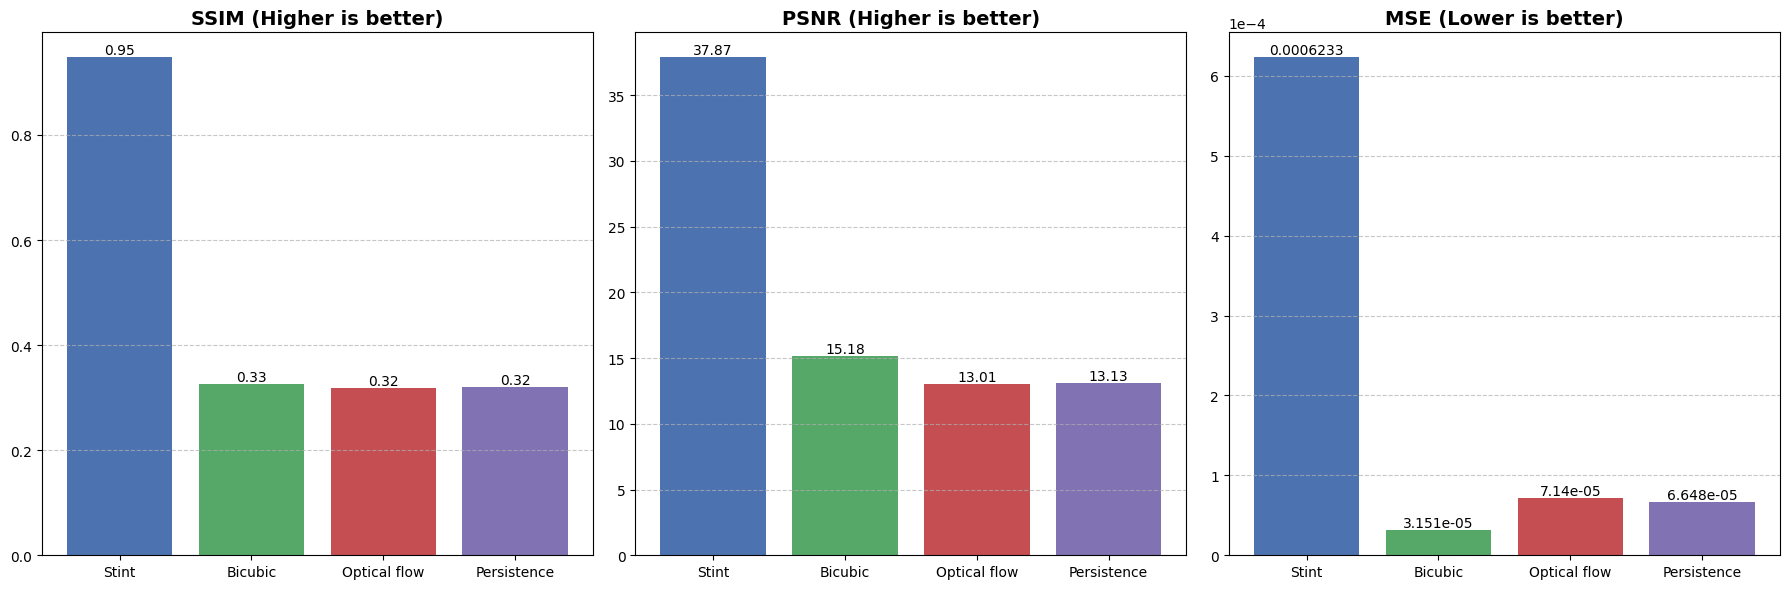

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
methods = ['Stint', 'Bicubic', 'Optical flow', 'Persistence']
ssim_values = [0.9479885787356349, 0.32600140044527953, 0.3176867254935835, 0.3198394127473892]
psnr_values = [37.87442127409459, 15.176702127139643, 13.005281990063057, 13.12755897615396]
mse_values = [0.0006232979220600913, 3.1513993674556884e-05, 7.140453824279428e-05, 6.64822646305592e-05]

metrics = {
    'SSIM (Higher is better)': ssim_values,
    'PSNR (Higher is better)': psnr_values,
    'MSE (Lower is better)': mse_values
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = ['#4c72b0', '#55a868', '#c44e52', '#8172b3']

for i, (metric_name, values) in enumerate(metrics.items()):
    ax = axes[i]
    bars = ax.bar(methods, values, color=colors)
    ax.set_title(metric_name, fontsize=14, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    if 'MSE' in metric_name:
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

    for bar in bars:
        height = bar.get_height()
        label = f'{height:.4g}' if height < 0.01 else f'{height:.2f}'
        ax.text(bar.get_x() + bar.get_width()/2., height,
                label, ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('comparison_metrics.png')

# Transfer learning

# Test model fine tuned on sintel

In [ ]:

class SintelDatasetFineTune(torch.utils.data.Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.clips = []

        if not os.path.exists(root_dir):
            raise ValueError(f"Directory {root_dir} introuvable.")

        scenes = sorted(os.listdir(root_dir))
        for scene in scenes:
            scene_path = os.path.join(root_dir, scene)
            if not os.path.isdir(scene_path): continue
            
            images = sorted([img for img in os.listdir(scene_path) if img.endswith(('.png', '.jpg'))])
            
            for i in range(0, len(images) - 7 + 1, 2): 
                self.clips.append([os.path.join(scene_path, images[j]) for j in range(i, i + 7)])

    def __len__(self):
        return len(self.clips)

    def __getitem__(self, idx):
        clip_paths = self.clips[idx]
        # Extraction des frames clés : 0, 3 (milieu), 6 (fin)
        indices_cles = [0, 3, 6]
        frames_out = []
        
        for i in indices_cles:
            img = Image.open(clip_paths[i]).convert('L') 
            if self.transform:
                img = self.transform(img)
            frames_out.append(img)
            
        return frames_out[0], frames_out[1], frames_out[2]

In [ ]:
def train_model(model, loader, val_loader, criterion, optimizer, num_epochs, alpha, device):
    train_losses = []
    val_losses = []

    print(f"Starting Fine-tuning")

    pbar_epoch = tqdm(range(num_epochs), desc="Global Progress")

    for epoch in pbar_epoch:
        model.train()
        current_train_loss = 0
        
        pbar_batch = tqdm(loader, desc=f"Epoch {epoch+1}", leave=False)
        
        for I0, I1, I2 in pbar_batch:
            I0, I1, I2 = I0.to(device), I1.to(device), I2.to(device)

            optimizer.zero_grad()
            s1_p1, s1_p2 = model(I0, I1)
            s1_p3, s1_p4 = model(I1, I2)
            s2_p1, s2_p2 = model(s1_p1, s1_p3)
            s2_p3, s2_p4 = model(s1_p2, s1_p4)

            loss = criterion(I1, s1_p2, s1_p3, s2_p1, s2_p2, s2_p3, s2_p4, alpha)
            loss.backward()
            optimizer.step()

            current_train_loss += loss.item()
            
            pbar_batch.set_postfix(current_loss=f"{loss.item():.4f}")

        avg_train_loss = current_train_loss / len(loader)
        train_losses.append(avg_train_loss)

        # --- Validation ---
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for vI0, vI1, vI2 in val_loader:
                vI0, vI1, vI2 = vI0.to(device), vI1.to(device), vI2.to(device)
                vs1_p1, vs1_p2 = model(vI0, vI1)
                vs1_p3, vs1_p4 = model(vI1, vI2)
                vs2_p1, vs2_p2 = model(vs1_p1, vs1_p3)
                vs2_p3, vs2_p4 = model(vs1_p2, vs1_p4)
                v_loss = criterion(vI1, vs1_p2, vs1_p3, vs2_p1, vs2_p2, vs2_p3, vs2_p4, alpha)
                val_loss += v_loss.item()
        
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        pbar_epoch.set_postfix(train_loss=f"{avg_train_loss:.4f}", val_loss=f"{avg_val_loss:.4f}")

    return train_losses, val_losses

In [ ]:
sintel_root = "../DATA/MPI-Sintel-training_images/training/final"
lr = 2e-5
epochs = 5

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

full_dataset = SintelDatasetFineTune(sintel_root, transform=transform)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# Datasets
train_ds, val_ds = torch.utils.data.random_split(full_dataset, [train_size, val_size])

loader = DataLoader(train_ds, batch_size=4, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=4, shuffle=False) 

model =UNetSE(2)
model.load_state_dict(torch.load('../OUTPUTS/30_epochs/model_30_epochs.pth'))
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = LCC()

# Lancement
train_model(model, loader, val_loader, criterion, optimizer, epochs, 1, 0.66, device)

In [45]:
ssim_metrics = 0
psnr_metrics = 0
mse_metrics = 0

with torch.no_grad():
    for I0, I1, I2, I3 in loader:

        I0 = I0.to(device)
        I3 = I3.to(device)

        I1 = I1.numpy().squeeze()
        I2 = I2.numpy().squeeze()

        I1_hat, I2_hat = model(I0, I3)
        I1_hat = I1_hat.detach().cpu().numpy().squeeze()
        I2_hat = I2_hat.detach().cpu().numpy().squeeze()

        ssim_metrics += ssim(I1, I1_hat, data_range=1)
        ssim_metrics += ssim(I2, I2_hat, data_range=1)

        psnr_metrics += psnr(I1, I1_hat, data_range=1)
        psnr_metrics += psnr(I2, I2_hat, data_range=1)

        mse_metrics += mse(I1, I1_hat)
        mse_metrics += mse(I2, I2_hat)

    print(f"SSIM = {ssim_metrics / (len(loader) * 2)}")
    print(f"PSNR = {psnr_metrics / (len(loader) * 2)}")
    print(f"MSE = {mse_metrics / (len(loader) * 2)}")

SSIM = 0.1603173586046282
PSNR = 9.608726469797649
MSE = 0.168596720858446


# Test baseline on sintel

### Bicubic

In [46]:
from scipy.interpolate import interp1d

ssim_metrics = 0
psnr_metrics = 0
mse_metrics = 0

original_time = np.array([0, 3])
target_time = np.array([1, 2])

print(f"Testing Bicubic Interpolation on {len(test_dataset)} samples...")

for I0, I1, I2, I3 in loader:

    I0 = I0.numpy().squeeze()
    I3 = I3.numpy().squeeze()
    I1_gt = I1.numpy().squeeze()
    I2_gt = I2.numpy().squeeze()

    # stack the known frames for interpolation
    known_frames = np.stack([I0, I3], axis=0)

    f_interp = interp1d(original_time, known_frames, kind='linear', axis=0)

    I1_hat = f_interp(1)
    I2_hat = f_interp(2)

    ssim_metrics += ssim(I1_gt, I1_hat, data_range=1.0)
    psnr_metrics += psnr(I1_gt, I1_hat, data_range=1.0)
    mse_metrics += mse(I1_gt, I1_hat)

    # Frame 2
    ssim_metrics += ssim(I2_gt, I2_hat, data_range=1.0)
    psnr_metrics += psnr(I2_gt, I2_hat, data_range=1.0)
    mse_metrics += mse(I2_gt, I2_hat)

total_frames = len(loader) * 2
print(f"\nResults for Bicubic/Linear Baseline:")
print(f"SSIM = {ssim_metrics / total_frames:.4f}")
print(f"PSNR = {psnr_metrics / total_frames:.4f}")
print(f"MSE  = {mse_metrics / total_frames:.6f}")

Testing Bicubic Interpolation on 528 samples...

Results for Bicubic/Linear Baseline:
SSIM = 0.7039
PSNR = 25.6767
MSE  = 0.007422


### Optical flow

In [ ]:
ssim_metrics = 0
psnr_metrics = 0
mse_metrics = 0

print(f"Testing Optical Flow (TV-L1) on {len(loader)} samples...")

for I0, I1, I2, I3 in loader:
    I0 = I0.numpy()[0]
    I3 = I3.numpy()[0]
    
    I0 = np.transpose(I0, (1, 2, 0))  # (C, H, W) -> (H, W, C)
    I3 = np.transpose(I3, (1, 2, 0))

    I1_gt = I1.numpy()[0]
    I2_gt = I2.numpy()[0]

    if I0.shape[2] == 1:
        I0 = I0.squeeze(2)
        I3 = I3.squeeze(2)

    # Calcul du Flux Optique entre I0 et I3
    flow = compute_tvl1(I0, I3)

    # Génération des frames intermédiaires (t=1/3 et t=2/3)
    # On s'assure que le résultat est au format (C, H, W) pour les métriques
    frame_interp_1 = get_intermediate_image(I0, flow, t=1/3) # (H, W) -> (1, H, W)
    frame_interp_2 = get_intermediate_image(I0, flow, t=2/3)
    
    if frame_interp_1.ndim == 3 and frame_interp_1.shape[-1] == I1_gt.shape[0]:
        frame_interp_1 = np.transpose(frame_interp_1, (2, 0, 1))
        frame_interp_2 = np.transpose(frame_interp_2, (2, 0, 1))
    
    # Si pred1 est [H, W] (gris) mais gt1 est [1, H, W]
    if frame_interp_1.ndim == 2 and I1_gt.ndim == 3:
        frame_interp_1 = frame_interp_1[np.newaxis, ...]
        frame_interp_2 = frame_interp_2[np.newaxis, ...]

    # Si get_intermediate_image renvoie (H, W, C), on transpose pour matcher gt
    if frame_interp_1.shape[-1] == 3:
        frame_interp_1 = np.transpose(frame_interp_1, (2, 0, 1))
        frame_interp_2 = np.transpose(frame_interp_2, (2, 0, 1))

    # Frame 1
    ssim_metrics += ssim(I1_gt, frame_interp_1, data_range=1.0, channel_axis=0)
    psnr_metrics += psnr(I1_gt, frame_interp_1, data_range=1.0)
    mse_metrics += mse(I1_gt, frame_interp_1)

    # Frame 2
    ssim_metrics += ssim(I2_gt, frame_interp_2, data_range=1.0, channel_axis=0)
    psnr_metrics += psnr(I2_gt, frame_interp_2, data_range=1.0)
    mse_metrics += mse(I2_gt, frame_interp_2)

# Normalisation finale
total_predicted_frames = len(loader) * 2
print(f"\nFinal Results (Optical Flow TV-L1):")
print(f"SSIM = {ssim_metrics / total_predicted_frames:.4f}")
print(f"PSNR = {psnr_metrics / total_predicted_frames:.4f}")
print(f"MSE  = {mse_metrics / total_predicted_frames:.6f}")

Testing Optical Flow (TV-L1) on 528 samples...

Final Results (Optical Flow TV-L1):
SSIM = 0.7677
PSNR = 26.2763
MSE  = 0.008602


### Persistence

In [ ]:
ssim_metrics = 0
psnr_metrics = 0
mse_metrics = 0

print(f"Testing Persistence Baseline on {len(loader)} samples...")

for I0, I1, I2, I3 in loader:

    pred1 = I0.squeeze(0).cpu().numpy()
    pred2 = I3.squeeze(0).cpu().numpy()
    
    gt1 = I1.squeeze(0).cpu().numpy()
    gt2 = I2.squeeze(0).cpu().numpy()

    ch_axis = 0 if gt1.ndim == 3 and gt1.shape[0] in [1, 3] else None

    ssim_metrics += ssim(gt1, pred1, data_range=1.0, channel_axis=ch_axis)
    psnr_metrics += psnr(gt1, pred1, data_range=1.0)
    mse_metrics += mse(gt1, pred1)

    ssim_metrics += ssim(gt2, pred2, data_range=1.0, channel_axis=ch_axis)
    psnr_metrics += psnr(gt2, pred2, data_range=1.0)
    mse_metrics += mse(gt2, pred2)

total_frames = len(loader) * 2
print(f"\n--- Résultats Persistence (Sintel) ---")
print(f"SSIM = {ssim_metrics / total_frames:.4f}")
print(f"PSNR = {psnr_metrics / total_frames:.4f}")
print(f"MSE  = {mse_metrics / total_frames:.6f}")

Testing Persistence Baseline on 528 samples...

--- Résultats Persistence (Sintel) ---
SSIM = 0.7004
PSNR = 24.1342
MSE  = 0.009900


### Comparison

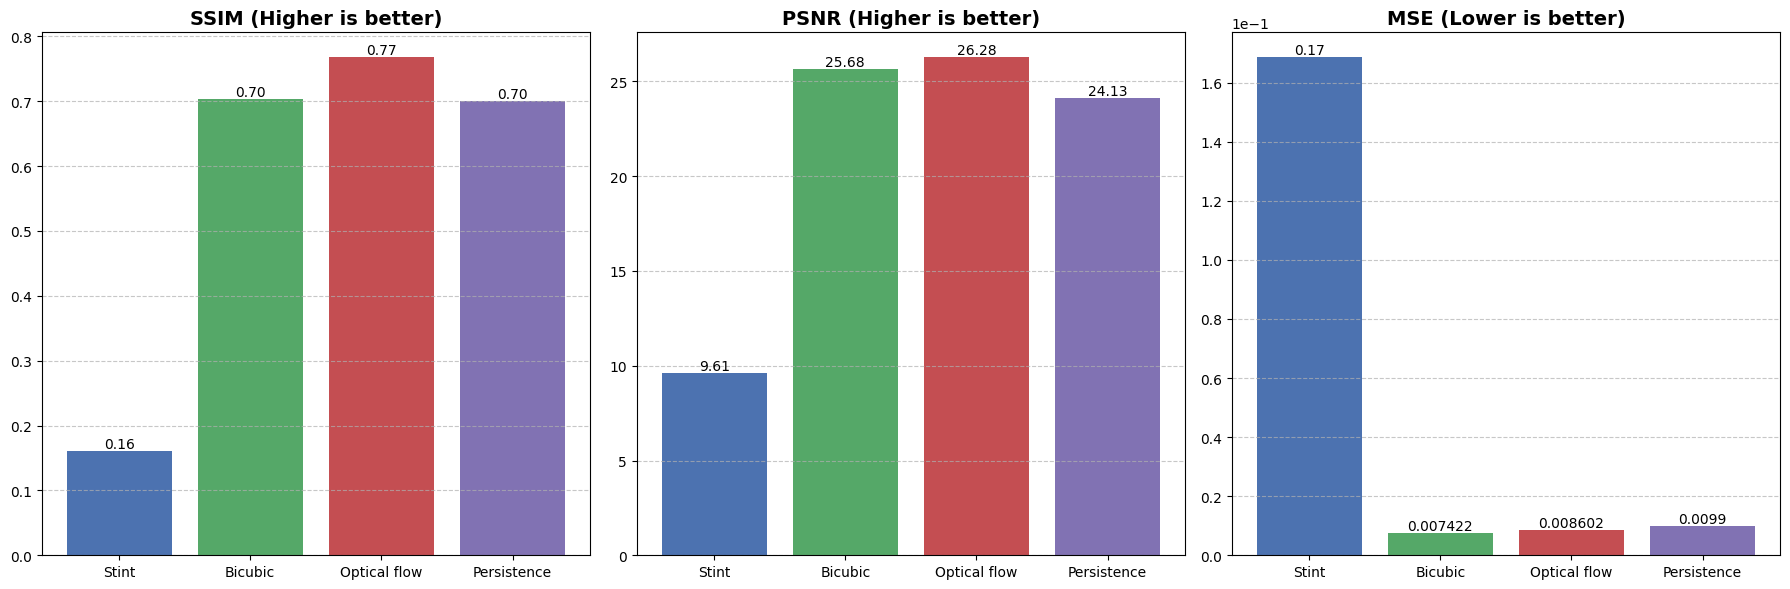

In [ ]:
# Data
methods = ['Stint', 'Bicubic', 'Optical flow', 'Persistence']
ssim_values = [0.1603173586046282, 0.7039, 0.7677, 0.7004]
psnr_values = [9.608726469797649, 25.6767, 26.2763, 24.1342]
mse_values = [0.168596720858446, 0.007422, 0.008602, 0.009900]

metrics = {
    'SSIM (Higher is better)': ssim_values,
    'PSNR (Higher is better)': psnr_values,
    'MSE (Lower is better)': mse_values
}

# Plot configuration
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = ['#4c72b0', '#55a868', '#c44e52', '#8172b3']

for i, (metric_name, values) in enumerate(metrics.items()):
    ax = axes[i]
    bars = ax.bar(methods, values, color=colors)
    ax.set_title(metric_name, fontsize=14, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Adjust y-axis for MSE if needed
    if 'MSE' in metric_name:
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

    # Add values on top of bars
    for bar in bars:
        height = bar.get_height()
        label = f'{height:.4g}' if height < 0.01 else f'{height:.2f}'
        ax.text(bar.get_x() + bar.get_width()/2., height,
                label, ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('comparison_metrics.png')